In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sqlalchemy import create_engine

engine = create_engine("postgresql://karnisinghrathore@localhost:5432/freight_analytics")
df = pd.read_sql("SELECT quarter_date, freight_cost FROM fact_freight_analysis ORDER BY quarter_date", engine)

# Prophet requires columns named exactly 'ds' (date) and 'y' (value)
prophet_df = df.rename(columns={"quarter_date": "ds", "freight_cost": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

print(f"Loaded {len(prophet_df)} quarters")
print(prophet_df.head())
print(prophet_df.tail())

Importing plotly failed. Interactive plots will not work.


Loaded 115 quarters
          ds     y
0 1997-09-01  64.3
1 1997-12-01  65.0
2 1998-03-01  64.7
3 1998-06-01  65.2
4 1998-09-01  65.2
            ds      y
110 2025-03-01  134.0
111 2025-06-01  134.9
112 2025-09-01  135.7
113 2025-12-01  137.4
114 2026-03-01  137.3


In [2]:
# Fit Prophet: yearly seasonality ON (captures festive/within-year pattern),
# weekly & daily OFF (meaningless for quarterly data), default trend flexibility.
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
model.fit(prophet_df)

# Build a future frame: 4 quarters (12 months) beyond the last data point
future = model.make_future_dataframe(periods=4, freq="QS")
forecast = model.predict(future)

# Show the forecast for the 4 future quarters
print("Forecast for next 4 quarters:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4).to_string(index=False))

09:49:26 - cmdstanpy - INFO - Chain [1] start processing
09:49:26 - cmdstanpy - INFO - Chain [1] done processing


Forecast for next 4 quarters:
        ds       yhat  yhat_lower  yhat_upper
2026-04-01 143.440492  140.578136  146.126615
2026-07-01 145.182819  142.723743  147.836965
2026-10-01 143.774438  141.263713  146.299636
2027-01-01 148.857542  146.404295  151.427964


In [3]:
# Use a quarter frequency that matches the data's actual months (Mar/Jun/Sep/Dec).
# 'QS-DEC' = quarter starts anchored so quarters begin Mar/Jun/Sep/Dec.

def fit_and_forecast(use_yearly):
    m = Prophet(
        yearly_seasonality=use_yearly,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    m.fit(prophet_df)
    fut = m.make_future_dataframe(periods=4, freq="QS-DEC")
    fc = m.predict(fut)
    return m, fc

# Version A: WITH yearly seasonality (your festive hypothesis)
m_yearly, fc_yearly = fit_and_forecast(True)

# Version B: WITHOUT yearly seasonality (trend only)
m_plain, fc_plain = fit_and_forecast(False)

print("Last actual:", prophet_df['ds'].iloc[-1].date(), "y =", prophet_df['y'].iloc[-1])
print("\nWITH yearly seasonality:")
print(fc_yearly[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4).to_string(index=False))
print("\nWITHOUT yearly seasonality (trend only):")
print(fc_plain[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4).to_string(index=False))

09:52:17 - cmdstanpy - INFO - Chain [1] start processing
09:52:17 - cmdstanpy - INFO - Chain [1] done processing
09:52:17 - cmdstanpy - INFO - Chain [1] start processing
09:52:17 - cmdstanpy - INFO - Chain [1] done processing


Last actual: 2026-03-01 y = 137.3

WITH yearly seasonality:
        ds       yhat  yhat_lower  yhat_upper
2026-06-01 141.068980  138.547260  143.703969
2026-09-01 142.236040  139.718726  144.748387
2026-12-01 143.623517  141.016212  146.089676
2027-03-01 144.479247  141.671182  147.205283

WITHOUT yearly seasonality (trend only):
        ds       yhat  yhat_lower  yhat_upper
2026-06-01 140.966370  138.588665  143.767860
2026-09-01 142.102348  139.585890  144.550026
2026-12-01 143.225978  140.544474  145.866998
2027-03-01 144.337261  141.898938  146.920215


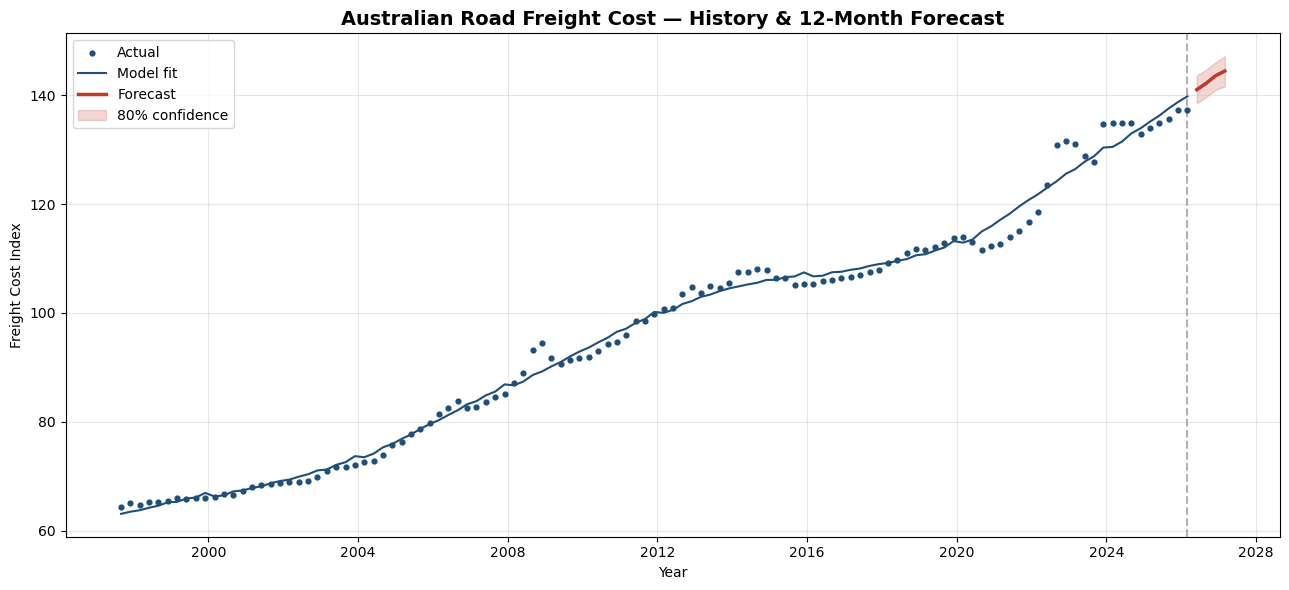

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

# Split history vs forecast at the last actual date
last_actual = prophet_df["ds"].max()
hist = fc_yearly[fc_yearly["ds"] <= last_actual]
fut  = fc_yearly[fc_yearly["ds"] >  last_actual]

# Actual historical values (dots)
ax.scatter(prophet_df["ds"], prophet_df["y"], s=12, color="#1f4e79",
           label="Actual", zorder=3)

# Model's fitted line over history
ax.plot(hist["ds"], hist["yhat"], color="#1f4e79", linewidth=1.5,
        label="Model fit")

# Forecast line (future)
ax.plot(fut["ds"], fut["yhat"], color="#c0392b", linewidth=2.5,
        label="Forecast")

# Confidence band over the forecast
ax.fill_between(fut["ds"], fut["yhat_lower"], fut["yhat_upper"],
                color="#c0392b", alpha=0.2, label="80% confidence")

ax.axvline(last_actual, color="gray", linestyle="--", alpha=0.6)
ax.set_title("Australian Road Freight Cost — History & 12-Month Forecast",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Freight Cost Index")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

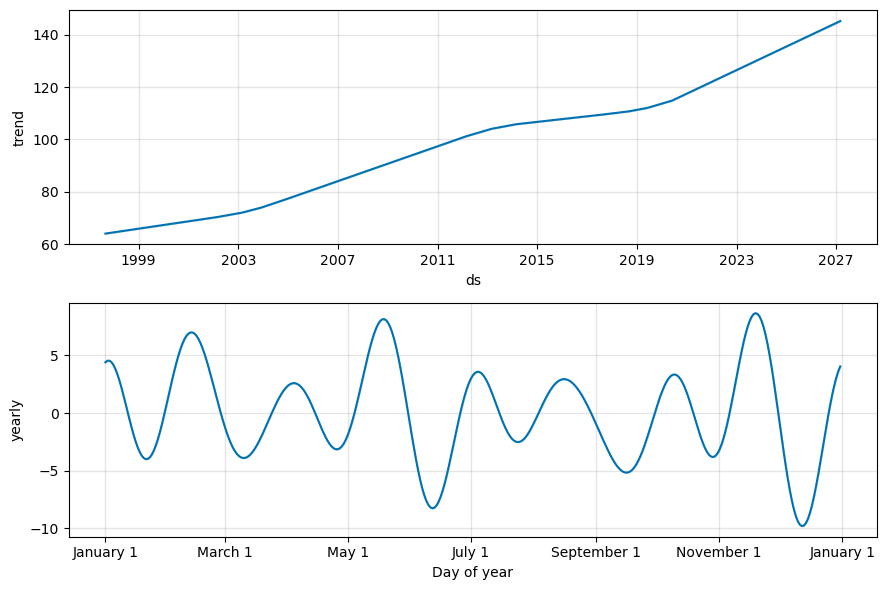

In [5]:
# Prophet's built-in component plot: trend + yearly seasonality
fig = m_yearly.plot_components(fc_yearly)
plt.show()

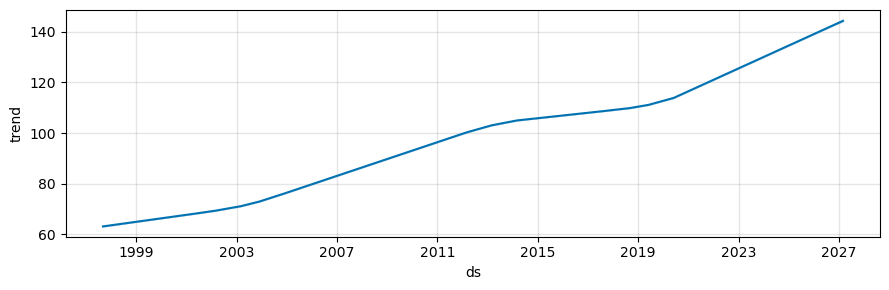


Final forecast (trend-only model):
        ds       yhat  yhat_lower  yhat_upper
2026-06-01 140.966370  138.588665  143.767860
2026-09-01 142.102348  139.585890  144.550026
2026-12-01 143.225978  140.544474  145.866998
2027-03-01 144.337261  141.898938  146.920215


In [6]:
# Adopt the trend-only model as FINAL (yearly seasonality overfit on quarterly data)
final_model = m_plain
final_forecast = fc_plain

# Confirm components are now clean (trend only, no noisy seasonal squiggle)
fig = final_model.plot_components(final_forecast)
plt.show()

print("\nFinal forecast (trend-only model):")
print(final_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4).to_string(index=False))

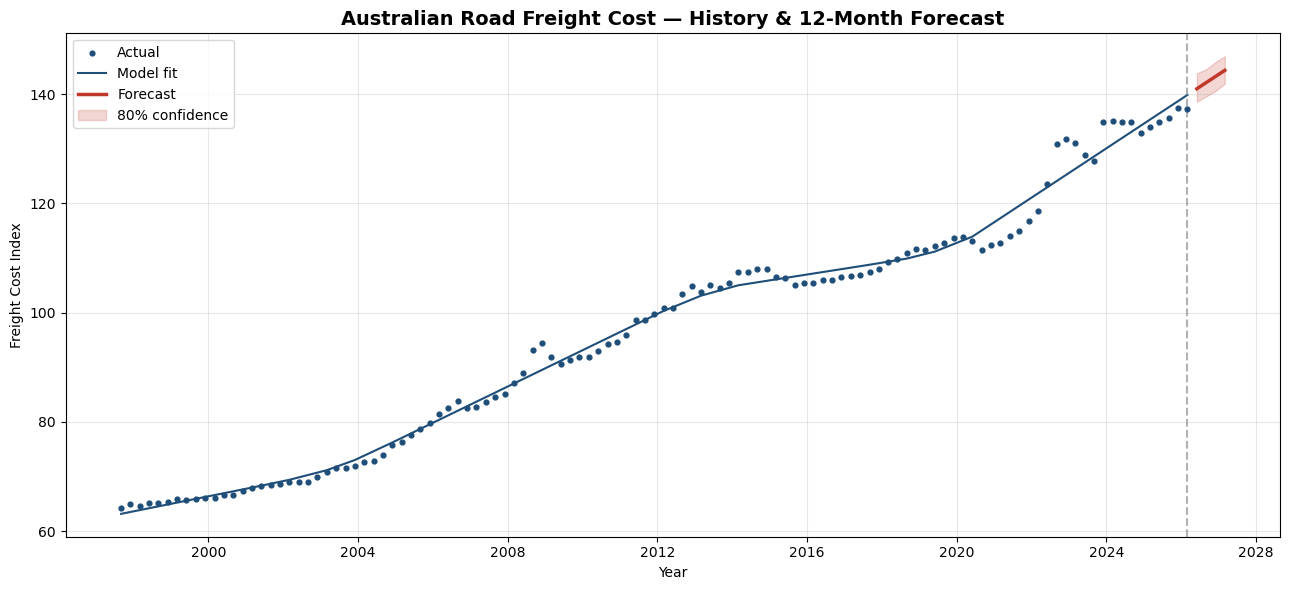

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

# Split history vs forecast at the last actual date
last_actual = prophet_df["ds"].max()
hist = final_forecast[final_forecast["ds"] <= last_actual]
fut  = final_forecast[final_forecast["ds"] >  last_actual]

# Actual historical values (dots)
ax.scatter(prophet_df["ds"], prophet_df["y"], s=12, color="#1f4e79",
           label="Actual", zorder=3)

# Model's fitted line over history
ax.plot(hist["ds"], hist["yhat"], color="#1f4e79", linewidth=1.5,
        label="Model fit")

# Forecast line (future)
ax.plot(fut["ds"], fut["yhat"], color="#c0392b", linewidth=2.5,
        label="Forecast")

# Confidence band over the forecast
ax.fill_between(fut["ds"], fut["yhat_lower"], fut["yhat_upper"],
                color="#c0392b", alpha=0.2, label="80% confidence")

ax.axvline(last_actual, color="gray", linestyle="--", alpha=0.6)
ax.set_title("Australian Road Freight Cost — History & 12-Month Forecast",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Freight Cost Index")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
from sqlalchemy import text

# Prepare the full forecast output (history + future) for storage
forecast_out = final_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_out.columns = ["quarter_date", "forecast", "forecast_lower", "forecast_upper"]

# Flag which rows are actual-period fits vs true future predictions
last_actual = prophet_df["ds"].max()
forecast_out["is_future"] = forecast_out["quarter_date"] > last_actual

# Create the table fresh each time (drop if exists), then write
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS forecast_results;"))

forecast_out.to_sql("forecast_results", engine, if_exists="append", index=False)

print(f"Stored {len(forecast_out)} rows in forecast_results "
      f"({forecast_out['is_future'].sum()} future quarters).")
print(forecast_out.tail(6).to_string(index=False))

Stored 119 rows in forecast_results (4 future quarters).
quarter_date   forecast  forecast_lower  forecast_upper  is_future
  2025-12-01 138.719109      136.046817      141.178462      False
  2026-03-01 139.830392      137.213986      142.450212      False
  2026-06-01 140.966370      138.588665      143.767860       True
  2026-09-01 142.102348      139.585890      144.550026       True
  2026-12-01 143.225978      140.544474      145.866998       True
  2027-03-01 144.337261      141.898938      146.920215       True
